# Lab: Pandas in 10 Minutes

- This notebook is based on the [Pandas User Guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html).

In [1]:
import numpy as np

In [2]:
# %pip install pandas    ### comment out after installation
import pandas as pd

In [3]:
# %pip install matplotlib ### comment out after installation
import matplotlib.pyplot as plt

## Basic data structures in pandas

Pandas provides two types of data structures for handling data:

**Series**: a **one-dimensional labeled array** holding data of **any type**
such as integers, strings, Python objects, etc.

**DataFrame**: a **two-dimensional** data structure that holds data like a two-dimension array or a table with rows and columns.

## Object creation
### Series
Creating a Series by passing a **list** of values, letting pandas create a default RangeIndex. Note that in the example below we have an element `np.nan`, which is a special floating-point value provided by the NumPy library that represents "Not a Number" (NaN). It is commonly used to indicate missing or undefined data in arrays or datasets.

In [4]:
ser = pd.Series( [1, 3, 5, np.nan, 6, 8]  )

In [5]:
ser

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64

In [6]:
### check data type
type(ser)

pandas.core.series.Series

### DataFrame from date_range( )

Creating a DataFrame by passing a **NumPy array** with a datetime index using [date_range()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.date_range.html#pandas.date_range) and labeled columns:

In [7]:
### you should check out date_range() by visiting the link provided above; 
### but for now, just observe the behavior of date_range()
### there's a date, and then there's a period parameter with a value of 6 assigned

dates = pd.date_range( "20250901", periods = 6)

In [8]:
### evaluate the object
dates

### You will see that there are 6 dates!!
### often time, these function/object behaviors are well designed by the 
### engineers, but we don't have the time to dig and learn about them just yet
### so, just observe and learn, and use them!

DatetimeIndex(['2025-09-01', '2025-09-02', '2025-09-03', '2025-09-04',
               '2025-09-05', '2025-09-06'],
              dtype='datetime64[ns]', freq='D')

In [9]:
### check the type of the object

print(type(dates))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [10]:
### the first date
### note the indexing starts from 0
### notice the format of the date

print( dates[0] )   

2025-09-01 00:00:00


### Bigger DataFrame
Now that we know the behavior of the **date_range()** function, let us use it:
- The function np.random.randn( ) generates random numbers from a standard normal (Gaussian) distribution.
- The normal distribution is with a mean (loc) of 0 and a standard deviation (scale) of 1
- Shape: You can pass integer arguments to randn() to specify the dimensions of the output array. For example, np.random.randn(6, 4) will create a 6x4 array of random numbers.
- The **list('ABCD') will output ['A', 'B', 'C', 'D'], which we covered before.

In [11]:
np.random.seed(42)  # seed for reproducibility
df = pd.DataFrame(
    data=np.random.randn(6, 4),
    index=dates,
    columns=list('ABCD')
)
df

,A,B,C,D
2025-09-01,0.496714,-0.138264,0.647689,1.523030
2025-09-02,-0.234153,-0.234137,1.579213,0.767435
2025-09-03,-0.469474,0.542560,-0.463418,-0.465730
2025-09-04,0.241962,-1.913280,-1.724918,-0.562288
2025-09-05,-1.012831,0.314247,-0.908024,-1.412304
2025-09-06,1.465649,-0.225776,0.067528,-1.424748


### Dictionary to DataFrame
Now, let us create a DataFrame by passing a **dictionary** of objects:
- where the **keys** are the **column labels** and
- the **values** are the **column values**.

In [12]:
df2 = pd.DataFrame(
    {
        'A': [1., 2, 3, 4],                                         ### a list; ints will be upcasted to floats
        'B': pd.Timestamp('20250925'),                              ### different without quote
        'C': pd.Series(1, index=list(range(4)), dtype='float32'),   ### a series
        'D': np.array([3] * 4, dtype='int32'),                      ### a numpy array    
        'E': pd.Categorical(["test", "train", "test", "train"]),    ### a categorical variable; ignore for now
        'F': 'foo'                                                  ### a constant value and will be propagated to all rows   
    }
)

### the keys are the column names and the values are the data

In [13]:
df2

,A,B,C,D,E,F
0,1.0,2025-09-25,1.0,3,test,foo
1,2.0,2025-09-25,1.0,3,train,foo
2,3.0,2025-09-25,1.0,3,test,foo
3,4.0,2025-09-25,1.0,3,train,foo


The columns of the resulting DataFrame have different data types (see: [Pandas **dtype<span style="color:red">s**</span>](https://pandas.pydata.org/pandas-docs/stable/user_guide/basics.html#basics-dtypes)):

In [14]:
### check the data types of each column

df2.dtypes

### note that Pandas automatically assign category and object to E and F

A          float64
B    datetime64[s]
C          float32
D            int32
E         category
F           object
dtype: object

### Tab completion

Tab completion for column names (as well as public attributes) is automatically 
enabled. Here’s a subset of the attributes that will be completed. 

As you can see, the columns A, B, C, and D are automatically tab-completed. E and F are there as well; the rest of the attributes have been truncated for brevity.

In [15]:
%%script echo ""     
### the above line is a magic function to tell Jupyter not to run this cell.

df2.<TAB>

## View data

Use DataFrame.**head()** and DataFrame.**tail()** to view the top and bottom **rows** of the **frame**, respectively:

In [83]:
# df.head
df.head()     ### note that "df.head" will output a different view

,A,B,C,D,F
2025-09-01,0.000000,0.000000,0.647689,5.0,NaN
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0
2025-09-04,0.241962,-1.913280,-1.724918,5.0,3.0
2025-09-05,-1.012831,0.314247,-0.908024,5.0,4.0


In [84]:
df.tail(3)

,A,B,C,D,F
2025-09-04,0.241962,-1.913280,-1.724918,5.0,3.0
2025-09-05,-1.012831,0.314247,-0.908024,5.0,4.0
2025-09-06,1.465649,-0.225776,0.067528,5.0,5.0


Display the [DataFrame.**index**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.index.html#pandas.DataFrame.index) or [DataFrame.**columns**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.columns.html#pandas.DataFrame.columns) (these are the labels/indexes/keys):

In [87]:
df.index

DatetimeIndex(['2025-09-01', '2025-09-02', '2025-09-03', '2025-09-04',
               '2025-09-05', '2025-09-06'],
              dtype='datetime64[ns]', freq='D')

In [88]:
df.columns

Index(['A', 'B', 'C', 'D', 'F'], dtype='object')

Now, as I said:
1. Pandas is based on NumPy
2. When we need to do math/algebra, we need to use NumPy. 

Therefore, sometimes, we would return a NumPy representation of the underlying data with [**DataFrame.to_numpy()**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_numpy.html#pandas.DataFrame.to_numpy) `without` the index or column labels:

In [91]:
df.to_numpy()

array([[ 0.        ,  0.        ,  0.64768854,  5.        ,         nan],
       [-0.23415337, -0.23413696,  1.57921282,  5.        ,  1.        ],
       [-0.46947439,  0.54256004, -0.46341769,  5.        ,  2.        ],
       [ 0.24196227, -1.91328024, -1.72491783,  5.        ,  3.        ],
       [-1.01283112,  0.31424733, -0.90802408,  5.        ,  4.        ],
       [ 1.46564877, -0.2257763 ,  0.0675282 ,  5.        ,  5.        ]])

<div class="alert-info admonition note">
<p class="admonition-title">Note:</p> 
<span style="font-weight:600">
<ol>
<li> NumPy arrays have one dtype for the entire array while pandas DataFrames have one dtype per column</span>. 
<li> When you call DataFrame.to_numpy(), Pandas will find the NumPy dtype that can hold all of the dtypes in the DataFrame (upcast). 
<li> If the common data type is object, DataFrame.to_numpy() will require copying data.
</ol>
</div>

**describe( )** shows a quick **descriptive statistic** summary of your data:

In [93]:
### take a look at the dataframe again:
df

,A,B,C,D,F
2025-09-01,0.000000,0.000000,0.647689,5.0,NaN
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0
2025-09-04,0.241962,-1.913280,-1.724918,5.0,3.0
2025-09-05,-1.012831,0.314247,-0.908024,5.0,4.0
2025-09-06,1.465649,-0.225776,0.067528,5.0,5.0


In [97]:
### I know that this part will make much more sense if you have some realistic data
### it's just random numbers are used here for illustration purpose
### but you will see that these are very useful functions
### so, just learn them and use them!

df.describe()     ### super useful descriptive stats
### super useful descriptive stats
### super useful descriptive stats
### super useful descriptive stats

,A,B,C,D,F
count,6.000000,6.000000,6.000000,6.0,5.000000
mean,-0.001475,-0.252731,-0.133655,5.0,3.000000
std,0.837582,0.869059,1.168366,0.0,1.581139
min,-1.012831,-1.913280,-1.724918,5.0,1.000000
25%,-0.410644,-0.232047,-0.796872,5.0,2.000000
50%,-0.117077,-0.112888,-0.197945,5.0,3.000000
75%,0.181472,0.235685,0.502648,5.0,4.000000
max,1.465649,0.542560,1.579213,5.0,5.000000


In [98]:
df.values     ### just like to_numpy

array([[ 0.        ,  0.        ,  0.64768854,  5.        ,         nan],
       [-0.23415337, -0.23413696,  1.57921282,  5.        ,  1.        ],
       [-0.46947439,  0.54256004, -0.46341769,  5.        ,  2.        ],
       [ 0.24196227, -1.91328024, -1.72491783,  5.        ,  3.        ],
       [-1.01283112,  0.31424733, -0.90802408,  5.        ,  4.        ],
       [ 1.46564877, -0.2257763 ,  0.0675282 ,  5.        ,  5.        ]])

In [100]:
### A DataFrame looks much better than a NumPy array

df

,A,B,C,D,F
2025-09-01,0.000000,0.000000,0.647689,5.0,NaN
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0
2025-09-04,0.241962,-1.913280,-1.724918,5.0,3.0
2025-09-05,-1.012831,0.314247,-0.908024,5.0,4.0
2025-09-06,1.465649,-0.225776,0.067528,5.0,5.0


Transposing your data:

An super easy example of transposing (a new DataFrame):

In [143]:
lst = list(range(9))                ### 1D list from 0 to 8
arr = np.array(lst).reshape(3, 3)   ### reshape to a 3x3 2D array
df3 = pd.DataFrame(arr)             ### turn the 2D array to a DataFrame
df3                                 ### you don't have the labels/keys/indexes in NumPy array

,0,1,2
0,0,1,2
1,3,4,5
2,6,7,8


In [144]:
df3.T

### what if it doesn't always turn 90 degrees? ====> graphics 

,0,1,2
0,0,3,6
1,1,4,7
2,2,5,8


Now get back to df:

In [145]:
df

,A,B,C,D,F
2025-09-01,0.000000,0.000000,0.647689,5.0,NaN
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0
2025-09-04,0.241962,-1.913280,-1.724918,5.0,3.0
2025-09-05,-1.012831,0.314247,-0.908024,5.0,4.0
2025-09-06,1.465649,-0.225776,0.067528,5.0,5.0


In [146]:
### transpose df
df.T

,2025-09-01,2025-09-02,2025-09-03,2025-09-04,2025-09-05,2025-09-06
A,0.000000,-0.234153,-0.469474,0.241962,-1.012831,1.465649
B,0.000000,-0.234137,0.542560,-1.913280,0.314247,-0.225776
C,0.647689,1.579213,-0.463418,-1.724918,-0.908024,0.067528
D,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
F,NaN,1.000000,2.000000,3.000000,4.000000,5.000000


[DataFrame.sort_index( )](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sort_index.html#pandas.DataFrame.sort_index): sort by an axis (0 in this case):

In [156]:
### axis 1 is the columns; axis 0 is the rows
### df.sort_index( ) by default sorts by axis 0 (rows), ascending by default

df.sort_index(axis=0)   ### sort by axis 0 (rows), ascending by default

,A,B,C,D,F
2025-09-01,0.000000,0.000000,0.647689,5.0,NaN
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0
2025-09-04,0.241962,-1.913280,-1.724918,5.0,3.0
2025-09-05,-1.012831,0.314247,-0.908024,5.0,4.0
2025-09-06,1.465649,-0.225776,0.067528,5.0,5.0


In [159]:
### sorting by axis 1 (columns) and descending just for illustration

df.sort_index(axis=1, ascending=False)

,F,D,C,B,A
2025-09-01,NaN,5.0,0.647689,0.000000,0.000000
2025-09-02,1.0,5.0,1.579213,-0.234137,-0.234153
2025-09-03,2.0,5.0,-0.463418,0.542560,-0.469474
2025-09-04,3.0,5.0,-1.724918,-1.913280,0.241962
2025-09-05,4.0,5.0,-0.908024,0.314247,-1.012831
2025-09-06,5.0,5.0,0.067528,-0.225776,1.465649


In [162]:
### sorting by values
### the more you learn about this, the more you will like it

df.sort_values(by='B')
### note that ascending is True by default

,A,B,C,D,F
2025-09-04,0.241962,-1.913280,-1.724918,5.0,3.0
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0
2025-09-06,1.465649,-0.225776,0.067528,5.0,5.0
2025-09-01,0.000000,0.000000,0.647689,5.0,NaN
2025-09-05,-1.012831,0.314247,-0.908024,5.0,4.0
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0


## Indexing/Selection

**Note**: While standard Python/NumPy expressions for selecting and setting are intuitive and come in handy for interactive work, for production code, we recommend the optimized pandas data access methods, DataFrame.at(), DataFrame.iat(), DataFrame.loc() and DataFrame.iloc().

In [166]:
### check df first
df

,A,B,C,D,F
2025-09-01,0.000000,0.000000,0.647689,5.0,NaN
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0
2025-09-04,0.241962,-1.913280,-1.724918,5.0,3.0
2025-09-05,-1.012831,0.314247,-0.908024,5.0,4.0
2025-09-06,1.465649,-0.225776,0.067528,5.0,5.0


### Getitem ( [ ] )

#### Single column: passing in label
For a DataFrame, passing a single **label** selects a column and yields a **Series** equivalent to `df.A`:



In [167]:
df['A']

### you get the indices and the selected column

2025-09-01    0.000000
2025-09-02   -0.234153
2025-09-03   -0.469474
2025-09-04    0.241962
2025-09-05   -1.012831
2025-09-06    1.465649
Freq: D, Name: A, dtype: float64

For a DataFrame, passing a slice `:` selects matching rows:

#### Use slice notation: Row index

In [168]:
df[0:3]

,A,B,C,D,F
2025-09-01,0.000000,0.000000,0.647689,5.0,NaN
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0


#### Use slice notation: Labels
For custom labels, slicing/getitem behaves like .loc (stop is inclusive).

In [169]:
df['20250902':'2025-09-04']

,A,B,C,D,F
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0
2025-09-04,0.241962,-1.913280,-1.724918,5.0,3.0


### Selection by label

See more in [Selection by Label](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#indexing-label) using [DataFrame.loc( )](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.loc.html#pandas.DataFrame.loc) or [DataFrame.at( )](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.at.html#pandas.DataFrame.at).

- DataFrame.**loc**: Access a group of rows and columns by label(s) or a boolean array. Allows inputs:
  - single label (Note this returns the row as a Series.)
  - list or array of labels
  - slice object with labels
- DataFrame.**at**: Access a single value for a row/column label pair. .at does label-based lookups. Use at if you only need to get or set a single value in a DataFrame or Series.

Selecting a row matching a label:

In [170]:
### check df
df

,A,B,C,D,F
2025-09-01,0.000000,0.000000,0.647689,5.0,NaN
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0
2025-09-04,0.241962,-1.913280,-1.724918,5.0,3.0
2025-09-05,-1.012831,0.314247,-0.908024,5.0,4.0
2025-09-06,1.465649,-0.225776,0.067528,5.0,5.0


Selecting a row matching a label. Note this returns the row as a Series.



In [171]:
df.loc[dates[0]]

A    0.000000
B    0.000000
C    0.647689
D    5.000000
F         NaN
Name: 2025-09-01 00:00:00, dtype: float64

Select all rows (`:`) with a select column labels:

In [172]:
### all the rows (axis 0) and a list of column labels
df.loc[:, ['A', 'B']]

,A,B
2025-09-01,0.000000,0.000000
2025-09-02,-0.234153,-0.234137
2025-09-03,-0.469474,0.542560
2025-09-04,0.241962,-1.913280
2025-09-05,-1.012831,0.314247
2025-09-06,1.465649,-0.225776


For label slicing, both endpoints are included:

In [174]:
df.loc['20250902' : '20250904', ['A', 'B']]

,A,B
2025-09-02,-0.234153,-0.234137
2025-09-03,-0.469474,0.542560
2025-09-04,0.241962,-1.913280


Selecting a single row and column label returns a scalar:

In [175]:
df.loc[dates[0], 'A']

np.float64(0.0)

For getting fast access to a scalar (equivalent to the prior method):

In [176]:
df.at[dates[0],'A']

np.float64(0.0)

## Selection by position

See more in [Selection by Position](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#indexing-integer) using [DataFrame.iloc()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iloc.html#pandas.DataFrame.iloc) or [DataFrame.iat()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iat.html#pandas.DataFrame.iat).

Select via the position of the passed integers:

In [177]:
### check df
df

,A,B,C,D,F
2025-09-01,0.000000,0.000000,0.647689,5.0,NaN
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0
2025-09-04,0.241962,-1.913280,-1.724918,5.0,3.0
2025-09-05,-1.012831,0.314247,-0.908024,5.0,4.0
2025-09-06,1.465649,-0.225776,0.067528,5.0,5.0


In [178]:
df.iloc[3]

A    0.241962
B   -1.913280
C   -1.724918
D    5.000000
F    3.000000
Name: 2025-09-04 00:00:00, dtype: float64

Integer slices acts similar to NumPy/Python:

In [179]:
df.iloc[3:5, 0:2]

,A,B
2025-09-04,0.241962,-1.913280
2025-09-05,-1.012831,0.314247


Lists of integer position locations:

In [180]:
df.iloc[[1, 2, 4], [0, 2]]

,A,C
2025-09-02,-0.234153,1.579213
2025-09-03,-0.469474,-0.463418
2025-09-05,-1.012831,-0.908024


In [185]:
### NumPy fancy indexing is similar to iloc

lst = list(range(20))
arr = np.array(lst).reshape(5, 4)
print(arr, "\n")
### fancy indexing
print("specific rows:", arr[ [0, 2, 4] ], "\n")
print("specific scalars:", arr[ [0, 2, 4], [1, 2, 3] ])   ### pairs ofo row & column indices

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]] 

specific rows: [[ 0  1  2  3]
 [ 8  9 10 11]
 [16 17 18 19]] 

specific scalars: [ 1 10 19]


For slicing rows explicitly:

In [200]:
### rows 1 to 3 (not including 3) and all the columns

df.iloc[1:3, :]       ### same as below
# df.iloc[1:3][:]

,A,B,C,D,F
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0


For slicing columns explicitly:

In [198]:

df.iloc[:, 1:3]


,B,C
2025-09-01,0.000000,0.647689
2025-09-02,-0.234137,1.579213
2025-09-03,0.542560,-0.463418
2025-09-04,-1.913280,-1.724918
2025-09-05,0.314247,-0.908024
2025-09-06,-0.225776,0.067528


For getting a value explicitly:

In [203]:
df.iloc[1, 1]

np.float64(-0.23413695694918055)

For getting fast access to a scalar (equivalent to the prior method):

In [202]:
df.iat[1, 1]

np.float64(-0.23413695694918055)

## Boolean indexing

Select rows where `df.A` is greater than `0`.

In [205]:
df[df["A"] > 0]

,A,B,C,D,F
2025-09-04,0.241962,-1.913280,-1.724918,5.0,3.0
2025-09-06,1.465649,-0.225776,0.067528,5.0,5.0


Selecting values from a DataFrame where a boolean condition is met:

In [207]:
### "df > 0" serves as a mask instead of a condition

df[df > 0]

,A,B,C,D,F
2025-09-01,NaN,NaN,0.647689,5.0,NaN
2025-09-02,NaN,NaN,1.579213,5.0,1.0
2025-09-03,NaN,0.542560,NaN,5.0,2.0
2025-09-04,0.241962,NaN,NaN,5.0,3.0
2025-09-05,NaN,0.314247,NaN,5.0,4.0
2025-09-06,1.465649,NaN,0.067528,5.0,5.0


Using [isin()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.isin.html#pandas.Series.isin) method for filtering:

In [208]:
df2 = df.copy()
df2["E"] = [ "one", "one", "two", "three", "four", "three"]
df2

,A,B,C,D,F,E
2025-09-01,0.000000,0.000000,0.647689,5.0,NaN,one
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0,one
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0,two
2025-09-04,0.241962,-1.913280,-1.724918,5.0,3.0,three
2025-09-05,-1.012831,0.314247,-0.908024,5.0,4.0,four
2025-09-06,1.465649,-0.225776,0.067528,5.0,5.0,three


In [209]:
df2[df2["E"].isin(["two", "four"])]

,A,B,C,D,F,E
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0,two
2025-09-05,-1.012831,0.314247,-0.908024,5.0,4.0,four


## Setting
Setting a new column automatically aligns the data by the index:

In [ ]:
### note that the date_range does not align with df

s1 = pd.Series([1, 2, 3, 4, 5, 6], index = pd.date_range("20250902", periods=6))
### note that the date_range does not align with df
### it starts with 20250902 instead of 20250901

In [214]:
s1

2025-09-02    1
2025-09-03    2
2025-09-04    3
2025-09-05    4
2025-09-06    5
2025-09-07    6
Freq: D, dtype: int64

In [216]:
### observe how the new column aligns the data by the index

df["F"] = s1

In [57]:
df

,A,B,C,D,F
2025-09-01,0.496714,-0.138264,0.647689,1.523030,NaN
2025-09-02,-0.234153,-0.234137,1.579213,0.767435,1.0
2025-09-03,-0.469474,0.542560,-0.463418,-0.465730,2.0
2025-09-04,0.241962,-1.913280,-1.724918,-0.562288,3.0
2025-09-05,-1.012831,0.314247,-0.908024,-1.412304,4.0
2025-09-06,1.465649,-0.225776,0.067528,-1.424748,5.0


Setting values by label:

In [218]:
df.at[dates[0], "A"] = 0
df

,A,B,C,D,F
2025-09-01,0.000000,0.000000,0.647689,5.0,NaN
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0
2025-09-04,0.241962,-1.913280,-1.724918,5.0,3.0
2025-09-05,-1.012831,0.314247,-0.908024,5.0,4.0
2025-09-06,1.465649,-0.225776,0.067528,5.0,5.0


Setting values by position:

In [219]:
df.iat[0, 1] = 0

In [220]:
df.at[dates[0], "A"] = 0

Setting by assigning with a NumPy array:

In [221]:
df.loc[:, "D"] = np.array([5] * len(df))

In [222]:
### in case you have questions about the above column operation
np.array([5] * len(df))

array([5, 5, 5, 5, 5, 5])

The resutl of the prior setting operations:

In [223]:
df

,A,B,C,D,F
2025-09-01,0.000000,0.000000,0.647689,5.0,NaN
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0
2025-09-04,0.241962,-1.913280,-1.724918,5.0,3.0
2025-09-05,-1.012831,0.314247,-0.908024,5.0,4.0
2025-09-06,1.465649,-0.225776,0.067528,5.0,5.0


A `where` operation with setting:

In [64]:
df2 = df.copy()
df2[df2 > 0 ]= -df2
df2

,A,B,C,D,F
2025-09-01,0.000000,0.000000,-0.647689,-5.0,NaN
2025-09-02,-0.234153,-0.234137,-1.579213,-5.0,-1.0
2025-09-03,-0.469474,-0.542560,-0.463418,-5.0,-2.0
2025-09-04,-0.241962,-1.913280,-1.724918,-5.0,-3.0
2025-09-05,-1.012831,-0.314247,-0.908024,-5.0,-4.0
2025-09-06,-1.465649,-0.225776,-0.067528,-5.0,-5.0


## Missing data

For NumPy data types, `np.nan` represents missing data. It is by default not included in computations. See the [Missing Data section](https://pandas.pydata.org/pandas-docs/stable/user_guide/missing_data.html#missing-data).

Reindexing (**reindex( )**) allows you to change/add/delete the index on a specified axis. This returns a copy of the data:

In [65]:
df1 = df.reindex(index=dates[0:4], columns=list(df.columns) + ["E"])
df1.loc[dates[0] : dates[1], "E"] = 1
df1


,A,B,C,D,F,E
2025-09-01,0.000000,0.000000,0.647689,5.0,NaN,1.0
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0,1.0
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0,NaN
2025-09-04,0.241962,-1.913280,-1.724918,5.0,3.0,NaN


[DataFrame.**dropna( )**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html#pandas.DataFrame.dropna) drops any rows that have missing data:

In [66]:
df1.dropna(how="any")

### only one row left that does not have missing data

,A,B,C,D,F,E
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0,1.0


[DataFrame.**fillna( )**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html#pandas.DataFrame.fillna) fills missing data:

In [67]:
df1.fillna(value=5)

,A,B,C,D,F,E
2025-09-01,0.000000,0.000000,0.647689,5.0,5.0,1.0
2025-09-02,-0.234153,-0.234137,1.579213,5.0,1.0,1.0
2025-09-03,-0.469474,0.542560,-0.463418,5.0,2.0,5.0
2025-09-04,0.241962,-1.913280,-1.724918,5.0,3.0,5.0


[**isna( )**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.isna.html#pandas.isna) gets the boolean mask where values are `nan`:

In [68]:
pd.isna(df1)

,A,B,C,D,F,E
2025-09-01,False,False,False,False,True,False
2025-09-02,False,False,False,False,False,False
2025-09-03,False,False,False,False,False,True
2025-09-04,False,False,False,False,False,True


## Operations

See the [Basic section on Binary Ops](https://pandas.pydata.org/pandas-docs/stable/user_guide/basics.html#basics-binop).

### Stats

- Operations in general **exclude** missing data.

Calculate the mean value for each column:

In [69]:
print(df, "\n")
print(df.mean())

                   A         B         C    D    F
2025-09-01  0.000000  0.000000  0.647689  5.0  NaN
2025-09-02 -0.234153 -0.234137  1.579213  5.0  1.0
2025-09-03 -0.469474  0.542560 -0.463418  5.0  2.0
2025-09-04  0.241962 -1.913280 -1.724918  5.0  3.0
2025-09-05 -1.012831  0.314247 -0.908024  5.0  4.0
2025-09-06  1.465649 -0.225776  0.067528  5.0  5.0 

A   -0.001475
B   -0.252731
C   -0.133655
D    5.000000
F    3.000000
dtype: float64


Calculate the mean value for each row:

In [70]:
df.mean(axis=1)

2025-09-01    1.411922
2025-09-02    1.422184
2025-09-03    1.321934
2025-09-04    0.920753
2025-09-05    1.478678
2025-09-06    2.261480
Freq: D, dtype: float64

Operating with another [Series](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.html#pandas.Series) or [DataFrame](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html#pandas.DataFrame) with a different index or column will align the result with the union of the index or column labels. In addition, pandas automatically broadcasts along the specified dimension and will fill unaligned labels with `np.nan`.

In [71]:
### shift() shifts the values of a Series or DataFrame along a 
### specified axis by a given number of periods.

s = pd.Series([1, 3, 5, np.nan, 6, 8], index=dates).shift(periods=2)
s

2025-09-01    NaN
2025-09-02    NaN
2025-09-03    1.0
2025-09-04    3.0
2025-09-05    5.0
2025-09-06    NaN
Freq: D, dtype: float64

In [72]:
print(df, "\n")
print(df.sub(s, axis="index"))

### sub() calculates the difference between corresponding elements 
### of the DataFrame and the other object. *broadcasting

                   A         B         C    D    F
2025-09-01  0.000000  0.000000  0.647689  5.0  NaN
2025-09-02 -0.234153 -0.234137  1.579213  5.0  1.0
2025-09-03 -0.469474  0.542560 -0.463418  5.0  2.0
2025-09-04  0.241962 -1.913280 -1.724918  5.0  3.0
2025-09-05 -1.012831  0.314247 -0.908024  5.0  4.0
2025-09-06  1.465649 -0.225776  0.067528  5.0  5.0 

                   A         B         C    D    F
2025-09-01       NaN       NaN       NaN  NaN  NaN
2025-09-02       NaN       NaN       NaN  NaN  NaN
2025-09-03 -1.469474 -0.457440 -1.463418  4.0  1.0
2025-09-04 -2.758038 -4.913280 -4.724918  2.0  0.0
2025-09-05 -6.012831 -4.685753 -5.908024  0.0 -1.0
2025-09-06       NaN       NaN       NaN  NaN  NaN


## User defined functions

In [73]:
0.190794 - 5

-4.809206

In [74]:
ts = pd.Series(np.random.randn(10), index=pd.date_range('1/1/2000', periods=10))


In [75]:
ts.describe

<bound method NDFrame.describe of 2000-01-01   -0.544383
2000-01-02    0.110923
2000-01-03   -1.150994
2000-01-04    0.375698
2000-01-05   -0.600639
2000-01-06   -0.291694
2000-01-07   -0.601707
2000-01-08    1.852278
2000-01-09   -0.013497
2000-01-10   -1.057711
Freq: D, dtype: float64>

<Axes: >

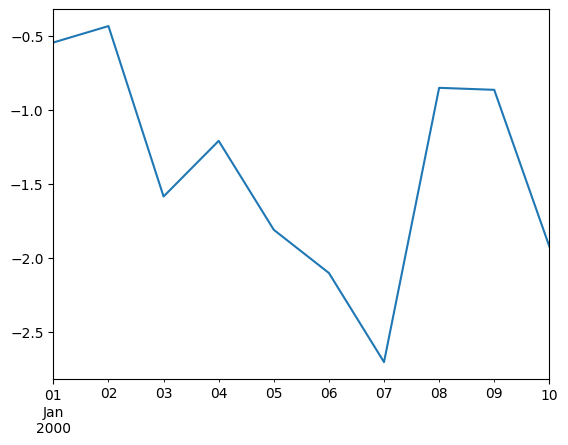

In [76]:
ts = ts.cumsum()
ts.plot()

In [77]:
ts.mean()

np.float64(-1.4020584591123506)

In [78]:
print('hello, world')

hello, world


In [79]:
import time

In [80]:
time.ctime()

'Thu Oct  2 04:13:38 2025'